# 23: What Does One Attachment Cause?

This chapter moves from screens to direct intervention and separates persistent state change from transient cascade.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


## V1 estimator failure and V2 zero-distance trap


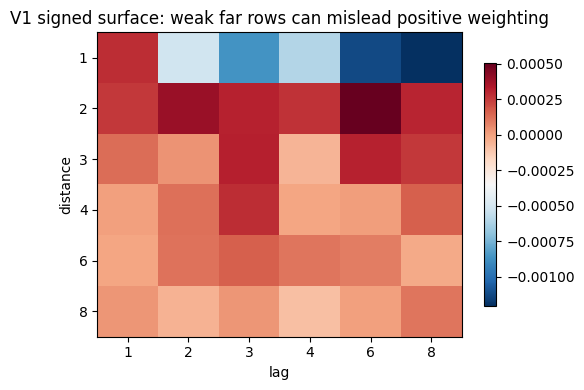

{'label': 'V1/V2 failures',
 'source': 'canonical research artifact',
 'observed': {'v1_status': 'FAILED',
  'v1_paired_p': 0.10717856428714258,
  'v2_status': 'PARTIAL_SOURCE_SINK_SUPPORT',
  'zero_distance_rule': 'd=0 source/control states are definitionally different and must be separated'}}

In [2]:
v1lag = load_json("research/digital-life/ch23-active-process-propagation-v1/stage-02-lag-distance.json")
v1 = load_json("research/digital-life/ch23-active-process-propagation-v1/stage-03-verdict.json")
surface = np.array(v1lag["population_real_excess_surface"])
fig, ax = plt.subplots(figsize=(5.5,4))
im = ax.imshow(surface, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(v1lag["lags"])), v1lag["lags"]); ax.set_yticks(range(len(v1lag["distances"])), v1lag["distances"])
ax.set(xlabel="lag", ylabel="distance", title="V1 signed surface: weak far rows can mislead positive weighting")
fig.colorbar(im, ax=ax, shrink=.8); fig.tight_layout()
fig.savefig(FIG_DIR / "ch23-v1-estimator-audit.png", bbox_inches="tight"); plt.show()
v2 = load_json("research/digital-life/ch23-interface-source-sink-v2/stage-04-verdict.json")
audit("V1/V2 failures", {
    "v1_status": v1["status"],
    "v1_paired_p": v1["paired_signflip_p_value"],
    "v2_status": v2["overall_source_sink_status"],
    "zero_distance_rule": "d=0 source/control states are definitionally different and must be separated",
}, source="canonical research artifact")


## V3 force/prevent and V4 persistent/transient split


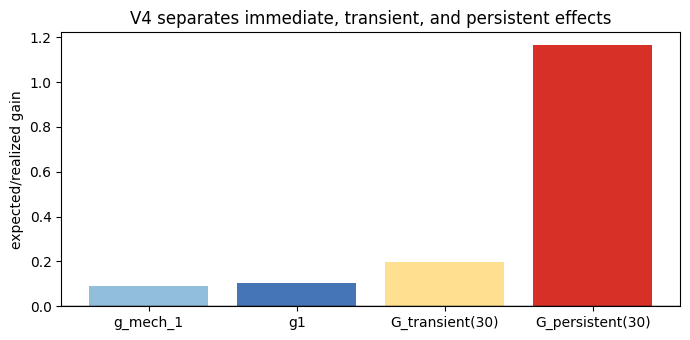

{'label': 'V3/V4 causal gain',
 'source': 'canonical research artifact',
 'observed': {'v3_g_mech_1': 0.10466201188269579,
  'v3_g1': 0.11458333333333333,
  'v3_G10_local': 0.5833333333333334,
  'v4_g_mech_1': 0.08832963949609172,
  'v4_g1': 0.1015625,
  'v4_transient_G30': 0.19791666666666666,
  'v4_late_transient_gain_per_update': -0.008072916666666667,
  'v4_persistent_G30': 1.1640625,
  'persistent_minus_transient': 0.9661458333333334,
  'overall_status': 'TRANSIENT_CASCADE_CONVERGES_NO_PERSISTENT_OFFSET_ESTABLISHED'}}

In [3]:
v3gain = load_json("research/digital-life/ch23-causal-attachment-gain-v3/stage-02-causal-gain.json")
v4dec = load_json("research/digital-life/ch23-persistent-transient-causal-gain-v4/stage-02-decomposition.json")
v4 = load_json("research/digital-life/ch23-persistent-transient-causal-gain-v4/stage-04-verdict.json")
labels = ["g_mech_1", "g1", "G_transient(30)", "G_persistent(30)"]
vals = [
    v4dec["g_mech_1"]["mean"],
    v4dec["persistent_g1"]["mean"],
    v4dec["transient_G_H_local"]["mean"],
    v4dec["persistent_G_H_local"]["mean"],
]
fig, ax = plt.subplots(figsize=(7,3.5))
ax.bar(labels, vals, color=["#91bfdb", "#4575b4", "#fee090", "#d73027"]); ax.axhline(0, color="black", lw=1)
ax.set(title="V4 separates immediate, transient, and persistent effects", ylabel="expected/realized gain")
fig.tight_layout(); fig.savefig(FIG_DIR / "ch23-v4-persistent-transient-audit.png", bbox_inches="tight"); plt.show()
audit("V3/V4 causal gain", {
    "v3_g_mech_1": v3gain["g_mech_1"]["mean"],
    "v3_g1": v3gain["g1_realized_ring1"]["mean"],
    "v3_G10_local": v3gain["G_H_local"]["mean"],
    "v4_g_mech_1": v4dec["g_mech_1"]["mean"],
    "v4_g1": v4dec["persistent_g1"]["mean"],
    "v4_transient_G30": v4dec["transient_G_H_local"]["mean"],
    "v4_late_transient_gain_per_update": v4dec["transient_late_mean"]["mean"],
    "v4_persistent_G30": v4dec["persistent_G_H_local"]["mean"],
    "persistent_minus_transient": v4dec["persistent_G_H_local"]["mean"] - v4dec["transient_G_H_local"]["mean"],
    "overall_status": v4["overall_status"],
}, source="canonical research artifact")


## Bounded claim

Immediate one-step gain is mechanically accounted for by the local rule. V3 mixed persistent level shift with transient cascade; V4 separates them. Persistent state change is not the same thing as transient causal cascade.

## Provenance

Current local book chapter: `content/books/digital-life/23-what-does-one-attachment-cause/index.md` (local working tree authority)

Research scripts: `ch23_digital_crystal_active_process_propagation_v1.py`, `ch23_digital_crystal_interface_source_sink_v2.py`, `ch23_digital_crystal_causal_attachment_gain_v3.py`, `ch23_digital_crystal_persistent_transient_causal_gain_v4.py`

Canonical artifacts: `research/digital-life/ch23-active-process-propagation-v1/`, `ch23-interface-source-sink-v2/`, `ch23-causal-attachment-gain-v3/`, `ch23-persistent-transient-causal-gain-v4/`

Notebook figures: `ch23-v1-estimator-audit.png`, `ch23-v4-persistent-transient-audit.png`

Execution mode: canonical-artifact-audit

## Claim Ledger

FAILED: V1 propagation screen; V2 source/sink story.

SUPPORTED: V3/V4 immediate local gain consistent with frozen mechanics; V4 persistent effect exceeds transient effect.

ASSERTION: d=0 is not neighbourhood dynamics because source/control states differ by definition.

UNTESTED: branching ratio or criticality terminology.
